# Customer Engagement & Click Probability Modeling
**Dataset:** Retailrocket E-Commerce Dataset (100K sample)  
**Author:** Harshit  
**GitHub:** https://github.com/harshitd697/customer-engagement-modeling

## 1. Imports

In [2]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.8 MB/s eta 0:00:00


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, confusion_matrix

print('All libraries imported successfully!')

All libraries imported successfully!


## 2. Load Data

In [4]:
# Load 100K rows from Retailrocket events.csv
df = pd.read_csv('events.csv', nrows=100000)

print('Raw Data Shape:', df.shape)
print(df.head())

Raw Data Shape: (100000, 5)
       timestamp  visitorid event  itemid  transactionid
0  1433221332117     257597  view  355908            NaN
1  1433224214164     992329  view  248676            NaN
2  1433221999827     111016  view  318965            NaN
3  1433221955914     483717  view  253185            NaN
4  1433221337106     951259  view  367447            NaN


## 3. Data Cleaning & Target Variable

In [5]:
# Convert timestamp (milliseconds) to datetime
df['datetime'] = pd.to_datetime(df['timestamp'], unit='ms')

# Create target variable
# 0 = just viewed (no engagement)
# 1 = added to cart OR purchased (engaged)
df['target'] = df['event'].apply(
    lambda x: 1 if x in ['addtocart', 'transaction'] else 0
)

print('Target Distribution:')
print(df['target'].value_counts())
print(f'\nEngagement Rate: {df["target"].mean():.2%}')

Target Distribution:
target
0    96754
1     3246
Name: count, dtype: int64

Engagement Rate: 3.25%


## 4. Feature Engineering

In [6]:
# --- Temporal Features ---
df['hour']        = df['datetime'].dt.hour        # hour of day
df['day_of_week'] = df['datetime'].dt.dayofweek   # 0=Monday, 6=Sunday
df['month']       = df['datetime'].dt.month       # month

# --- Behavioral Features (per visitor) ---
visitor_stats = df.groupby('visitorid').agg(
    visitor_total_views  = ('event', 'count'),
    visitor_unique_items = ('itemid', 'nunique')
).reset_index()

# --- Contextual Features (per item) ---
item_stats = df.groupby('itemid').agg(
    item_total_views     = ('event', 'count'),
    item_unique_visitors = ('visitorid', 'nunique')
).reset_index()

# --- Merge Features Back ---
df = df.merge(visitor_stats, on='visitorid', how='left')
df = df.merge(item_stats,    on='itemid',    how='left')

print('Feature Engineering Done!')
print('Final Shape:', df.shape)
print(df[['hour','day_of_week','month',
          'visitor_total_views','visitor_unique_items',
          'item_total_views','item_unique_visitors','target']].head())

Feature Engineering Done!
Final Shape: (100000, 14)
   hour  day_of_week  month  visitor_total_views  visitor_unique_items  \
0     5            1      6                    1                     1   
1     5            1      6                    9                     7   
2     5            1      6                    1                     1   
3     5            1      6                    3                     2   
4     5            1      6                    1                     1   

   item_total_views  item_unique_visitors  target  
0                 2                     2       0  
1                 1                     1       0  
2                 2                     2       0  
3                 2                     1       0  
4                 6                     6       0  


## 5. Exploratory Data Analysis (EDA)

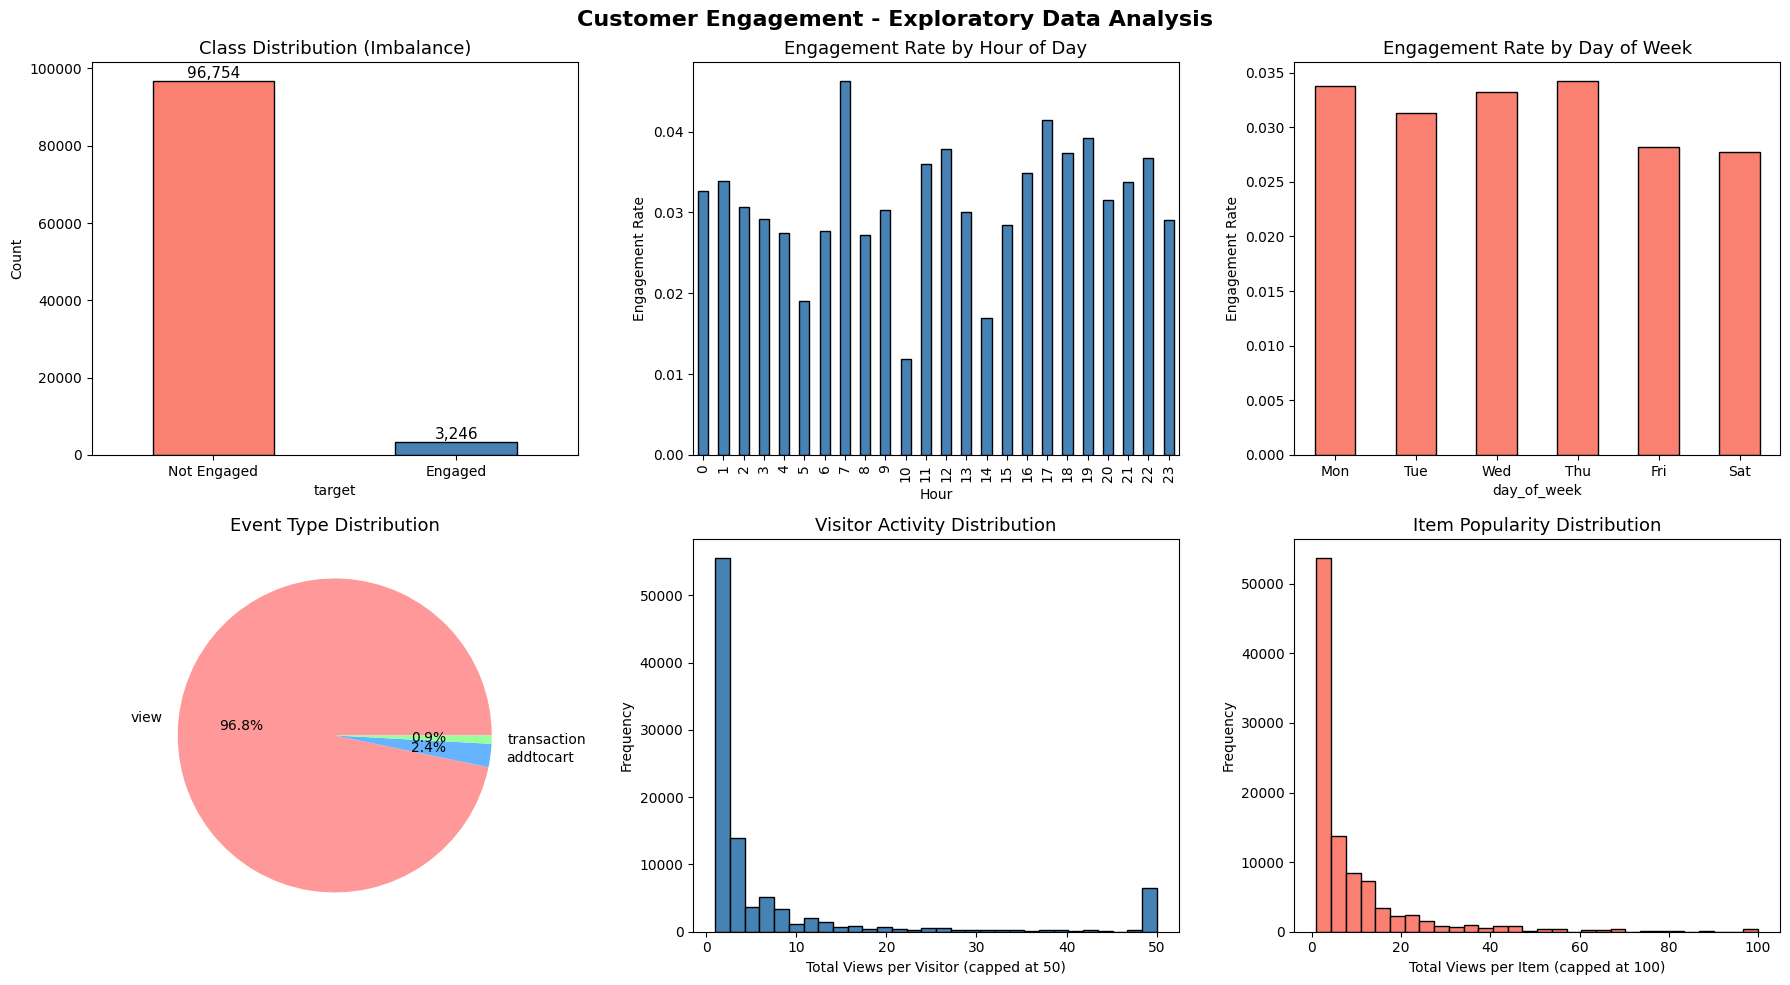

EDA plots saved!


In [7]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Customer Engagement - Exploratory Data Analysis',
             fontsize=16, fontweight='bold')

# Plot 1: Class Imbalance
df['target'].value_counts().plot(
    kind='bar', ax=axes[0,0], color=['salmon','steelblue'], edgecolor='black')
axes[0,0].set_title('Class Distribution (Imbalance)', fontsize=13)
axes[0,0].set_xticklabels(['Not Engaged','Engaged'], rotation=0)
axes[0,0].set_ylabel('Count')
for p in axes[0,0].patches:
    axes[0,0].annotate(f'{int(p.get_height()):,}',
                       (p.get_x()+p.get_width()/2, p.get_height()),
                       ha='center', va='bottom', fontsize=11)

# Plot 2: Engagement by Hour
df.groupby('hour')['target'].mean().plot(
    kind='bar', ax=axes[0,1], color='steelblue', edgecolor='black')
axes[0,1].set_title('Engagement Rate by Hour of Day', fontsize=13)
axes[0,1].set_xlabel('Hour')
axes[0,1].set_ylabel('Engagement Rate')

# Plot 3: Engagement by Day of Week
present_days = sorted(df['day_of_week'].unique())
days = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
df.groupby('day_of_week')['target'].mean().plot(
    kind='bar', ax=axes[0,2], color='salmon', edgecolor='black')
axes[0,2].set_title('Engagement Rate by Day of Week', fontsize=13)
axes[0,2].set_xticklabels([days[i] for i in present_days], rotation=0)
axes[0,2].set_ylabel('Engagement Rate')

# Plot 4: Event Type Distribution
df['event'].value_counts().plot(
    kind='pie', ax=axes[1,0], autopct='%1.1f%%',
    colors=['#ff9999','#66b3ff','#99ff99'])
axes[1,0].set_title('Event Type Distribution', fontsize=13)
axes[1,0].set_ylabel('')

# Plot 5: Visitor Activity Distribution
df['visitor_total_views'].clip(upper=50).plot(
    kind='hist', ax=axes[1,1], bins=30, color='steelblue', edgecolor='black')
axes[1,1].set_title('Visitor Activity Distribution', fontsize=13)
axes[1,1].set_xlabel('Total Views per Visitor (capped at 50)')

# Plot 6: Item Popularity Distribution
df['item_total_views'].clip(upper=100).plot(
    kind='hist', ax=axes[1,2], bins=30, color='salmon', edgecolor='black')
axes[1,2].set_title('Item Popularity Distribution', fontsize=13)
axes[1,2].set_xlabel('Total Views per Item (capped at 100)')

plt.tight_layout()
plt.savefig('eda_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print('EDA plots saved!')

## 6. Model Training

In [8]:
features = [
    'hour',
    'day_of_week',
    'month',
    'visitor_total_views',
    'visitor_unique_items',
    'item_total_views',
    'item_unique_visitors'
]

X = df[features]
y = df['target']

# Train/Validation Split (80/20, stratified)
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)

print(f'Train size: {X_train.shape[0]:,}')
print(f'Val size:   {X_val.shape[0]:,}')

# Handle class imbalance
scale = (y == 0).sum() / (y == 1).sum()
print(f'scale_pos_weight: {scale:.2f}')

Train size: 80,000
Val size:   20,000
scale_pos_weight: 29.81


In [9]:
# --- XGBoost ---
xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=scale,
    eval_metric='auc',
    random_state=42,
    verbosity=0
)
xgb_model.fit(X_train, y_train)
xgb_auc = roc_auc_score(y_val, xgb_model.predict_proba(X_val)[:, 1])
print(f'XGBoost AUC: {xgb_auc:.4f}')

XGBoost AUC: 0.8730


In [10]:
# --- CatBoost ---
cat_model = CatBoostClassifier(
    iterations=100,
    depth=6,
    learning_rate=0.1,
    random_seed=42,
    verbose=0
)
cat_model.fit(X_train, y_train)
cat_auc = roc_auc_score(y_val, cat_model.predict_proba(X_val)[:, 1])
print(f'CatBoost AUC: {cat_auc:.4f}')

winner = 'XGBoost' if xgb_auc > cat_auc else 'CatBoost'
print(f'\n Winner: {winner}!')

CatBoost AUC: 0.8524

 Winner: XGBoost!


## 7. Results Visualization

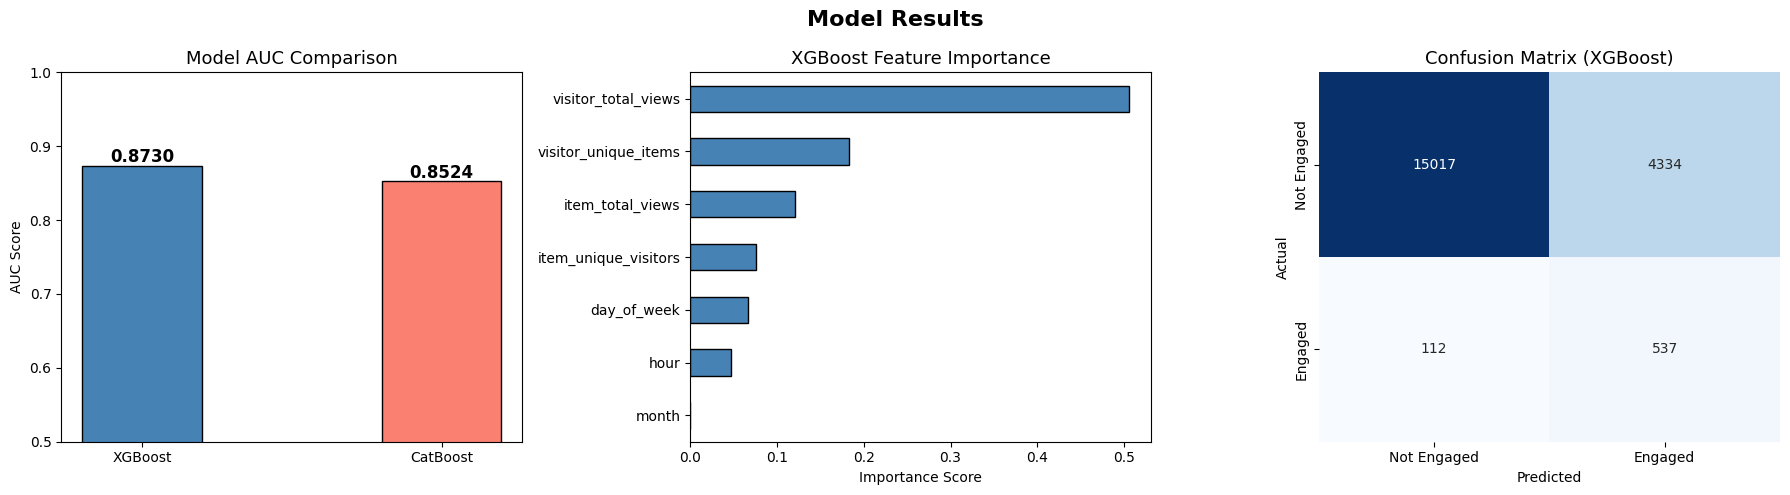

Model result plots saved!


In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Model Results', fontsize=16, fontweight='bold')

# Plot 1: Model Comparison
models = ['XGBoost', 'CatBoost']
aucs   = [xgb_auc, cat_auc]
bars = axes[0].bar(models, aucs, color=['steelblue','salmon'],
                   edgecolor='black', width=0.4)
axes[0].set_title('Model AUC Comparison', fontsize=13)
axes[0].set_ylabel('AUC Score')
axes[0].set_ylim(0.5, 1.0)
for bar, auc in zip(bars, aucs):
    axes[0].text(bar.get_x()+bar.get_width()/2,
                 bar.get_height()+0.005,
                 f'{auc:.4f}', ha='center', fontsize=12, fontweight='bold')

# Plot 2: Feature Importance
feat_imp = pd.Series(xgb_model.feature_importances_, index=features)
feat_imp.sort_values().plot(
    kind='barh', ax=axes[1], color='steelblue', edgecolor='black')
axes[1].set_title('XGBoost Feature Importance', fontsize=13)
axes[1].set_xlabel('Importance Score')

# Plot 3: Confusion Matrix
y_pred = xgb_model.predict(X_val)
cm = confusion_matrix(y_val, y_pred)
sns.heatmap(cm, annot=True, fmt='d', ax=axes[2],
            cmap='Blues', cbar=False,
            xticklabels=['Not Engaged','Engaged'],
            yticklabels=['Not Engaged','Engaged'])
axes[2].set_title('Confusion Matrix (XGBoost)', fontsize=13)
axes[2].set_ylabel('Actual')
axes[2].set_xlabel('Predicted')

plt.tight_layout()
plt.savefig('model_results.png', dpi=150, bbox_inches='tight')
plt.show()
print('Model result plots saved!')

## 8. Ranking Output — Top 5 Items per Visitor

In [12]:
df['predicted_prob'] = xgb_model.predict_proba(X)[:, 1]

top_items = (
    df.sort_values(['visitorid', 'predicted_prob'],
                   ascending=[True, False])
    .groupby('visitorid')
    .head(5)[['visitorid', 'itemid', 'predicted_prob']]
)

print('Top 5 Item Recommendations per Visitor:')
print(top_items.head(15))
top_items.to_csv('recommendations.csv', index=False)
print('\nRecommendations saved to recommendations.csv!')

Top 5 Item Recommendations per Visitor:
       visitorid  itemid  predicted_prob
10302         17  138434        0.096773
10861         52  108504        0.039338
28955         74   57171        0.638072
28980         74   57171        0.638072
44296         74   57171        0.638072
29014         74   45410        0.071233
29100         74   59574        0.071233
55401         91   79513        0.007903
37584        109  216019        0.100318
35635        122  301278        0.031707
5076         137  383819        0.007663
68923        162  248862        0.233661
58606        162  390093        0.152300
58598        162  305656        0.148071
57802        162    1152        0.044612

Recommendations saved to recommendations.csv!


## 9. Project Summary

In [13]:
print('=' * 50)
print('PROJECT SUMMARY')
print('=' * 50)
print(f'Total Records Processed : {len(df):,}')
print(f'Engagement Rate         : {df["target"].mean():.2%}')
print(f'Features Used           : {len(features)}')
print(f'XGBoost AUC             : {xgb_auc:.4f}')
print(f'CatBoost AUC            : {cat_auc:.4f}')
print(f'Winner Model            : {winner}')
print('=' * 50)

PROJECT SUMMARY
Total Records Processed : 100,000
Engagement Rate         : 3.25%
Features Used           : 7
XGBoost AUC             : 0.8730
CatBoost AUC            : 0.8524
Winner Model            : XGBoost
